# Внутри LLM: собираем RAG-бейзлайн



> Задача: для каждого вопроса юриста найти в корпусе судебных актов **один правильный документ** и вернуть его в **топ-5** кандидатов. Наша метрика - **Recall@5**.

В этом ноутбуке четыре шага:
1. **Мини-EDA** - что за данные и какие у них особенности;
2. **Бейзлайн TF-IDF** - простое решение без нейросетей;
3. **Метрика** - как считать Recall@5 точно так же, как это делает платформа;
4. **Сабмит** - как собрать и проверить файл отправки.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

pd.set_option('display.max_colwidth', None)

In [ ]:
# предполагаем, что файлы лежат рядом с ноутбуком / или в файлах колаба

docs  = pd.read_csv('documents.csv') # корпус: по нему ищем
train = pd.read_csv('train.csv') # тренировочные вопросы: ориентируемся на них
test  = pd.read_csv('test.csv') # вопросы без ответов: по ним лидерборд

print(f'документов: {len(docs)} | train: {len(train)} | test: {len(test)}')
docs.head(2)

документов: 468 | train: 700 | test: 350


,doc_id,text
0,d_006815a5ef,"Судья Мещанского районного суда адрес ФИО, ознакомившись с исковым заявлением ФИО к адрес «Достойное Будущее» о восстановлении срока для обращения с заявлением о выплате средств пенсионных накоплений умершего застрахованного лица,\n\nУСТАНОВИЛ:\nВ Мещанский районный суд адрес поступило исковое заявление ФИО к адрес «Достойное Будущее» о восстановлении срока для обращения с заявлением о выплате средств пенсионных накоплений умершего застрахованного лица.\nВместе с тем, указанное исковое заявление не может быть принято к производству суда.\nПунктом 4 ч.1 ст.135 ГПК РФ предусмотрено, что судья возвращает исковое заявление в случае, если исковое заявление не подписано или исковое заявление подписано и подано лицом, не имеющим полномочий на его подписание и предъявление в суд.\nКак усматривается из заявления, оно не подписано истцом,\nПри таких обстоятельствах, данное исковое заявление подлежит возврату.\nДанное обстоятельство не препятствует повторной подаче подписанного надлежащим лицом заявления.\nНа основании изложенного, руководствуясь положениями статьи 135 ГПК РФ, суд\n\nОПРЕДЕЛИЛ:\nИсковое заявление ФИО к адрес «Достойное Ббдущее» о восстановлении срока для обращения с заявлением о выплате средств пенсионных накоплений умершего застрахованного лица – возвратить истцу.\nВозвращение искового заявления не препятствует повторному обращению истца в суд с иском к тому же ответчику, о том же предмете и по тем же основаниям, если истцом будет устранено допущенное нарушение.\nНа определение может быть подана частная жалоба в Московский городской суд через Мещанский районный суд адрес в течение 15 дней.\nСудья ФИО\nРОССИЙСКАЯ ФЕДЕРАЦИЯ\nМещанский\nрайонный суд\nтел. телефон -74\nМ - 5087/2024\nФИО\nМещанский районный суд адрес направляет в Ваш адрес определение о возвращении искового заявления от 17.04.2024 года.\nПриложение:\n- определение о возвращении искового заявления;\n- копия искового заявления;\n- приложения к исковому заявлению;\n- оригинал квитанции об оплате госпошлины.\nСудья фио\nРОССИЙСКАЯ ФЕДЕРАЦИЯ\nМещанский\nрайонный суд\nтел. телефон -74\nМ - 5087/2024\nФИО\nМещанский районный суд адрес направляет в Ваш адрес определение о возвращении искового заявления от 17.04.2024 года.\nПриложение:\n- определение о возвращении искового заявления;\n- копия искового заявления;\n- приложения к исковому заявлению;\n- оригинал квитанции об оплате госпошлины.\nСудья фио"
1,d_012d59baeb,"Москва\nСудья Мещанского районного суда города Москвы ФИО, изучив исковое заявление ФИО к АО «НПФ Будущее» о восстановлении пропущенного срока для обращения правопреемника с заявлением о выплате средств пенсионных накоплений, учтенных на пенсионном счете накопительной пенсии умершего застрахованного лица,\n\nУСТАНОВИЛ:\nВ Мещанский районный суд города Москвы поступило исковое заявление ФИО к АО «НПФ Будущее» о восстановлении пропущенного срока для обращения правопреемника с заявлением о выплате средств пенсионных накоплений, учтенных на пенсионном счете накопительной пенсии умершего застрахованного лица.\nВ силу положений ст. 132 ГПК РФ к исковому заявлению, в числе прочего, прилагается документ, подтверждающий уплату государственной пошлины в установленных порядке и размере или право на получение льготы по уплате государственной пошлины, либо ходатайство о предоставлении отсрочки, рассрочки, об уменьшении размера государственной пошлины или об освобождении от уплаты государственной пошлины; уведомление о вручении или иные документы, подтверждающие направление другим лицам, участвующим в деле, копий искового заявления и приложенных к нему документов, которые у других лиц, участвующих в деле, отсутствуют, в том числе в случае подачи в суд искового заявления и приложенных к нему документов в электронном виде.\nОзнакомившись с иском, суд считает, что поданное заявление не соответствует указанным требованиям.\n08.09.2024 вступили в силу положения Федерального закона от 08.08.2024 № 259-ФЗ «О внесении изменений в части первую и 

## 1. Мини-EDA

Прежде чем что-то обучать - нам нужно взглянуть на данные. Три основные вопроса: **что ищем**, **среди чего ищем** и **где подвох**. :)

In [ ]:
# среди чего ищем - это наш корпус

print('Колонки документа:', list(docs.columns), '\n')

def doc_kind(t):
    head = t[:800].upper().replace(' ', '')
    if 'АПЕЛЛЯЦИОННОЕОПРЕДЕЛЕНИЕ' in head: return 'апелляционное определение'
    if 'КАССАЦИОН' in t[:1500].upper(): return 'кассационное определение'
    if 'РЕШЕНИЕ' in head[:300]: return 'решение'
    return 'определение'

def doc_instance(t):
    head = t[:1500].upper()
    if 'КАССАЦИОН' in head: return 'кассация'
    if 'АПЕЛЛЯЦИОН' in head: return 'апелляция'
    return 'первая инстанция'

print('Типы актов:')
print(docs['text'].apply(doc_kind).value_counts().to_string(), '\n')
print('Инстанции:')
print(docs['text'].apply(doc_instance).value_counts().to_string())

Колонки документа: ['doc_id', 'text'] 

Типы актов:
text
определение                  364
решение                       63
апелляционное определение     37
кассационное определение       4 

Инстанции:
text
первая инстанция    416
апелляция            41
кассация             11


In [ ]:
# длина документов
# корпус неоднородный - короткие определения и длинные решения

docs['len'] = docs['text'].str.len()
print(docs['len'].describe().round(0).to_string())

count      468.0
mean      6883.0
std       7608.0
min        813.0
25%       2024.0
50%       3376.0
75%       7805.0
max      45300.0


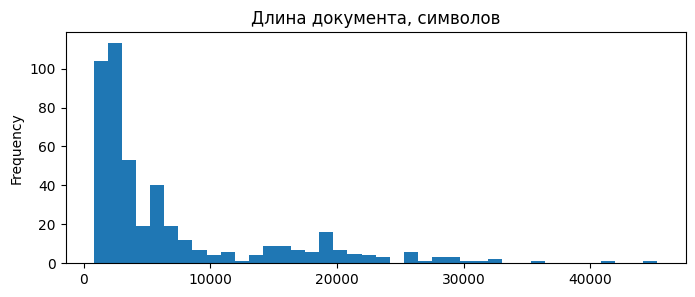

In [ ]:
docs['len'].plot(kind='hist', bins=40, figsize=(8,3), title='Длина документа, символов')
plt.show()

In [ ]:
# теперь что ищем - наши вопросы
# у train есть правильный ответ (gold_doc_id) и тема

print('Пример вопросов из train:')
for q in train['question'].sample(5, random_state=7):
    print(' •', q)
print()
print('Темы (topic):')
print(train['topic'].value_counts().head(8).to_string())

Пример вопросов из train:
 • Подберите дело о недействительности договора ОПС с частичным удовлетворением: накопления и проценты взысканы, в остальном отказано.
 • Можно ли доказать порок воли табелем учёта рабочего времени за день «подписания» договора?
 • Нужно ли включать пенсионные накопления в наследственную массу для восстановления срока?
 • Полная компенсация затрат на юриста: миф или достижимый результат в спорах с НПФ?
 • Судья отказался сам сравнивать подписи и требует почерковедческую экспертизу. Обоснованно ли это?

Темы (topic):
topic
переход в НПФ / недействительность волеизъявления    108
правопреемство / наследование                         85
инвестиционный доход и денежные расчеты               84
доказательства / почерковедческая экспертиза          74
процессуальные определения по движению иска           69
назначение и выплата пенсионных накоплений            57
судебные расходы                                      56
процессуальные сроки / исковая давность        

In [ ]:
# важная особенность корпуса
# правильные документы сконцентрированы в содержательных актах

gold_docs = train['gold_doc_id'].nunique()
print(f'уникальных правильных документов в train: {gold_docs} из {len(docs)} в корпусе')
print(f'то есть ~{len(docs)-gold_docs} документов — шум, который надо уметь отсеивать')

# и ещё: вопросы сформулированы содержательно - в них нет номеров дел, судов, дат и фамилий.
# поэтому поиск по точному совпадению строк работать не будет - придется искать по содержанию.

уникальных правильных документов в train: 113 из 468 в корпусе
то есть ~355 документов — шум, который надо уметь отсеивать


**Бонус train-разметки:** колонка `gold_evidence_text` - это дословный фрагмент документа, который отвечает на вопрос (с `gold_evidence_char_start/_end`). На ней удобно строить passage-level поиск и реранкеры. Проверим, что офсеты честные:

In [ ]:
row = train.iloc[0]
doc_text = docs.set_index('doc_id').loc[row['gold_doc_id'], 'text']
fragment = doc_text[int(row['gold_evidence_char_start']):int(row['gold_evidence_char_end'])]
assert fragment == row['gold_evidence_text'], 'офсеты должны совпадать с фрагментом!'
print('Вопрос:', row['question'])
print('\nОпорный фрагмент из документа:\n', fragment[:300], '…')

Вопрос: Какие признаки помогут доказать, что заявление о переходе в НПФ не подписывалось клиентом?

Опорный фрагмент из документа:
 ере….. руб., а также компенсацию морального вреда в размере …..руб.
Свои исковые требования истец мотивирует тем, что …. года между ней и АО «НПФ Сбербанка» был заключен договор об обязательном пенсионном страховании № ….., однако ….. года из телефонного разговора с представителем данного НПФ истцу  …


## 2. Бейзлайн: TF-IDF

> Идея: представить каждый документ и каждый вопрос как мешок слов с весами TF-IDF и мерить косинусную близость. Никакого обучения - только статистика корпуса.

Токенизация: слова из букв/цифр длиной >= 3, нижний регистр, без стоп-слов.

In [ ]:
TOKEN = re.compile(r'[а-яёa-z0-9]+', re.I)

# словарь стоп слов составили сами - на основе трейна
RU_STOP = set('и в во не что он на я с со как а то все она так его но да ты к у же вы за бы по только ее мне было вот от меня еще нет о из ему когда даже ну ли если уже или ни быть был него до вас уж вам ведь там потом себя ничего ей может они тут где есть надо ней для мы тебя их чем была сам без чего раз тоже себе под будет тогда кто этот того потому этого какой ним здесь этом один мой тем чтобы нее были куда зачем всех при два об другой хоть после над больше тот через эти нас про всего них какая много три эту перед лучше том такой им более всю между'.split())

def tok(s):
    return [w for w in TOKEN.findall(str(s).lower()) if len(w) > 2 and w not in RU_STOP]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

vec = TfidfVectorizer(tokenizer=tok, lowercase=False, token_pattern=None)
D = vec.fit_transform(docs['text']) # матрица документов: (468 x |словарь|)
doc_ids = docs['doc_id'].tolist()
print('матрица документов:', D.shape)

матрица документов: (468, 9129)


Определим и вспомогательную функцию, которая будет возвращать нам топ пять документов по убыванию косинусной близовсти. Что она делает?

Для списка вопросов возвращает список топ-5 doc_id - по убыванию близости.

In [ ]:
def retrieve_top5(questions):
    Q = vec.transform(questions)
    sims = linear_kernel(Q, D) # косинус: TF-IDF уже L2-нормирован
    order = np.argsort(-sims, axis=1)[:, :5] # индексы 5 ближайших документов
    return [[doc_ids[j] for j in row] for row in order]

train_pred = retrieve_top5(train['question'])
print('пример выдачи для первого вопроса:', train_pred[0])

пример выдачи для первого вопроса: ['d_c43cad7282', 'd_a3ea97ebfc', 'd_04ba7f2e18', 'd_8357734cfe', 'd_3837ffb996']


## 3. Метрика: Recall@5 — считаем как платформа


По условию задания - на каждый вопрос ровно **один** правильный документ. Recall@5 - доля вопросов, у которых он попал в присланную пятерку:

$$\text{Recall@5}=\frac{1}{N}\sum_{i=1}^{N}\mathbb{1}\big[g_i \in \text{top5}_i\big]$$

Три детали, которые часто путают:
- **порядок внутри пятёрки не важен** - попал на 5-е место = всё еще попал;
- **дубликаты не помогают** - один и тот же документ дважды остается одним кандидатом;
- **больше 5 нельзя** - платформа отклонит файл, а локально лишние строки до метрики не доедут.

Напишем функцию, эквивалентную платформенной:

In [ ]:
# gold - правильный doc_id на вопрос; preds - списки кандидатов
# gовторы убираем, оставляем не более 5 - ровно как чекер платформы

def recall_at_5(gold: pd.Series, preds: list) -> float:
    hits = 0
    for g, p in zip(gold, preds):
        seen, top5 = set(), []
        for d in p: # дедупликация с сохранением порядка
            if d not in seen:
                seen.add(d); top5.append(d)
            if len(top5) == 5:
                break
        hits += int(g in top5)
    return hits / len(gold)

r5 = recall_at_5(train['gold_doc_id'], train_pred)
print(f'TF-IDF Recall@5 на train: {r5:.4f}')

TF-IDF Recall@5 на train: 0.3371


In [ ]:
# куда смотреть дальше? на чём бейзлайн ошибается?

miss = [(q, g, p[0]) for q, g, p in zip(train['question'], train['gold_doc_id'], train_pred) if g not in p]
print(f'промахов: {len(miss)} из {len(train)}\n')
for q, g, p1 in miss[:3]:
    print('Вопрос:  ', q[:110])
    print('  нужен: ', g, '| TF-IDF выбрал:', p1, '\n')

# типичная причина: вопрос сформулирован "по-человечески", а документ - канцеляским языком,
# общих слов мало. Это лечится лемматизацией, BM25 и эмбеддингами.

промахов: 464 из 700

Вопрос:   Какие факты помогли фонду убедить суд, что переход был осознанным выбором клиента?
  нужен:  d_a9a59816ed | TF-IDF выбрал: d_d0b30d09b3 

Вопрос:   Куда направляются пенсионные накопления умершего, если никто из надлежащих правопреемников не обратился за вып
  нужен:  d_68874c6ad6 | TF-IDF выбрал: d_4e8802e636 

Вопрос:   Возражаем против иска: переход оформлял посредник, истец ссылается на обман. Что нужно доказать об осведомлённ
  нужен:  d_1e525dd61f | TF-IDF выбрал: d_b5c5cd5746 



## 4. Сабмит

Файл отправки - CSV с заголовком `qid,doc_id`: **по одной строке на документ**, до 5 строк на вопрос, первая строка вопроса = ваш лучший кандидат.

Перед отправкой прогоняем те же проверки, что сделает платформа, - дешевле поймать ошибку локально.

In [ ]:
test_pred = retrieve_top5(test['question'])

submission = pd.DataFrame(
    [(qid, d) for qid, p in zip(test['qid'], test_pred) for d in p],
    columns=['qid', 'doc_id'],
)

# самопроверка формата
assert list(submission.columns) == ['qid', 'doc_id'], 'ровно две колонки: qid,doc_id'
assert submission.notna().all().all(), 'пропусков быть не должно'
assert not submission.duplicated(['qid', 'doc_id']).any(), 'без повторов пары (qid, doc_id)'
assert submission.groupby('qid').size().max() <= 5, 'не более 5 строк на вопрос'
assert set(submission['qid']) == set(test['qid']), 'ответ на каждый вопрос теста'
assert submission['doc_id'].isin(docs['doc_id']).all(), 'только существующие doc_id'

submission.to_csv('submission.csv', index=False)
print('submission.csv готов:', submission.shape[0], 'строк на', test["qid"].nunique(), 'вопросов')
submission.head(7)

submission.csv готов: 1750 строк на 350 вопросов


,qid,doc_id
0,q_025ed27ba2,d_61e313b506
1,q_025ed27ba2,d_48b105390f
2,q_025ed27ba2,d_d235ca1c7e
3,q_025ed27ba2,d_21e0ba1f08
4,q_025ed27ba2,d_a3ea97ebfc
5,q_0288552f11,d_b2f62b4d48
6,q_0288552f11,d_c965cc1c03


## Как нам улучшить результат?

Попробуйте следующие улучшения - они распределены по возрастанию сложности:

1. **Лемматизация**. Для русского языка можно использовать [pymorphy3](https://pypi.org/project/pymorphy3/). То есть мы слова "накоплений/накопления/накоплениям" приведем к одной единой лемме - начальной (словарной) форме слова.
2. **BM25**. `rank_bm25` будет лучше работать, чем TF-IDF, поскольку он справляется эффективнее с длинными документами.
3. **Dense-эмбеддинги**. Попробуйте подключить модели (например, e5 или bge), можно закодировать вопрос и документ, или *чанки* документа, и поискать по косинусному расстоянию. Для e5 не забудьте префиксы `query:` / `passage:`.
4. **Чанкинг**. Это важный и полезный момент: документы у нас длинные, можно  порезать их на абзацы, а затем считать близость вопроса к чанкам. Нужный документ оценивайте по максимуму. Тут как раз может пригодиться `gold_evidence_text` из train.
5. **Cross-encoder реранкер**. Делаем его поверх топ-20 кандидатов первого этапа. Должно увеличить скор.
6. **Гибрид**. Собираем несколько решений вместе, например, BM25 + dense через Reciprocal Rank Fusion - почти всегда лучше каждого по отдельности.

И помните такой момент: в наших документах сотни шаблонных определений-дистракторов. Они похожи друг на друга. И выигрывает тот, кто отличает конкретный прецедент, а не просто тему.